# Redução de dimensionalidade no SVM com metadados spaCy

**Pergunta:** reduzir a dimensão do bloco de texto (TF-IDF word+char, ~114 mil features) com `TruncatedSVD` diminui o overfitting do SVM atual (F1 treino = 1,0, gap ≈ 0,07) sem perder desempenho em notícias não vistas?

**Setup fixo:** nada de C, w ou folds é re-buscado aqui.
- Modelo: **M2** = word+char + meta_spacy. É a melhor configuração no Fake.br no notebook 10: `LinearSVC(C=1, class_weight="balanced", dual=False)`, peso do bloco spaCy **w = 0,03**, CV 0,9344.
- Mesmos folds: `StratifiedKFold(5, shuffle=True, random_state=42)`.
- B0 (word+char puro, C=1) entra no mesmo d para separar o efeito da redução do efeito do spaCy.
- Varia só a dimensão do texto: `TruncatedSVD(d) + Normalizer`, d ∈ {50, 100, 200, 300, 500}, contra o texto completo. O bloco spaCy (24 features) nunca é reduzido.
- O SVD é ajustado **dentro de cada fold**, só no treino do fold, em float32 por limite de memória da máquina.

**Como ler o gap:** gap = F1 treino − F1 CV. Ele só indica menos overfitting se o **F1 CV se mantiver**. Se o gap cair porque o F1 de treino caiu e o de CV caiu junto, é underfitting, não generalização (ver `REDUCAO_DIMENSIONALIDADE.md`).

**Regra de escolha de d, fixada antes de rodar e só com a CV:** entre os d cujo Δ pareado contra o M2 completo é **≥ −0,01** (empate pelo critério do time), escolher o de **menor gap**. Se nenhum d passar, a conclusão é que a redução não diminui o overfitting sem custo. Nesse caso, o d com melhor F1 CV vai ao teste só para informação.

**FakeRecogna:** só uma espiada. São títulos (~13 palavras) contra um treino de 100 palavras, então não é um parâmetro confiável e não escolhe nada.

In [1]:
import gc
import time
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, Normalizer, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

pd.set_option("display.width", 200)

X_tr, X_te, y_tr, y_te = joblib.load("../../data/dados_preparados.pkl")
configs = joblib.load("../../data/transformers.pkl")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parâmetros fixos: melhor M2 no Fake.br (notebook 10, resultados_svm_meta_cv.csv)
res10 = pd.read_csv("../resultados/resultados_svm_meta_cv.csv")
m2_10 = res10[(res10.config == "M2") & (res10.k_chi2 == "all")].sort_values("f1_cv").iloc[-1]
C, W = float(m2_10.C), float(m2_10.w_meta)
print(f"M2 do notebook 10: C={C}, w={W}, F1 CV {m2_10.f1_cv:.4f}")

# meta_spacy final do notebook 10, seção 4 (após remover constantes e |r| > 0,9)
META_SPACY = ['pos_ADJ', 'pos_ADP', 'pos_AUX', 'pos_CCONJ', 'pos_DET', 'pos_NOUN', 'pos_NUM', 'pos_PRON',
              'pos_PROPN', 'pos_PUNCT', 'pos_VERB', 'dep_nsubj', 'dep_obj', 'dep_obl', 'dep_nmod', 'dep_advmod',
              'dep_amod', 'dep_ccomp', 'dep_xcomp', 'dep_mark', 'taxa_sentencas', 'tam_medio_sentenca_sp',
              'verbo_subjuntivo', 'pessoa_1_2']
feats = pd.read_parquet("../../data/metadados_spacy.parquet")  # gerado pelo notebook 10
X_tr = X_tr.join(feats.loc[X_tr.index, META_SPACY])
X_te = X_te.join(feats.loc[X_te.index, META_SPACY])

SVC = LinearSVC(C=C, class_weight="balanced", random_state=42, max_iter=20000, dual=False)
DIMS = [50, 100, 200, 300, 500]

M2 do notebook 10: C=1.0, w=0.03, F1 CV 0.9344


## 1. Blocos por fold

**Pergunta:** quanto custa preparar cada fold? Em cada fold, o TF-IDF, cada `TruncatedSVD(d)` e o scaler do spaCy são ajustados só no treino do fold e aplicados na validação. O `Normalizer` (L2 por linha, como no notebook 08) não tem `fit`.

In [2]:
def meta_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])

folds = []
t_total = time.time()
for i, (tr, va) in enumerate(cv.split(X_tr, y_tr)):
    Xa, Xb = X_tr.iloc[tr], X_tr.iloc[va]
    f = {"y_tr": y_tr.iloc[tr].values, "y_va": y_tr.iloc[va].values, "txt": {}}
    ct = ColumnTransformer(configs["word+char"]).fit(Xa)
    Ta, Tb = ct.transform(Xa).tocsr(), ct.transform(Xb).tocsr()
    f["txt"]["all"] = (Ta, Tb)
    Ta32 = Ta.astype(np.float32)  # float32 no SVD: metade da memória (a máquina tem ~4 GB livres)
    for d in DIMS:
        svd = TruncatedSVD(n_components=d, random_state=42).fit(Ta32)
        norm = Normalizer()
        f["txt"][d] = (norm.transform(svd.transform(Ta32)), norm.transform(svd.transform(Tb.astype(np.float32))))
        f.setdefault("var", {})[d] = svd.explained_variance_ratio_.sum()
        del svd
        gc.collect()
    del Ta32
    mp = meta_pipe().fit(Xa[META_SPACY])
    f["meta"] = (mp.transform(Xa[META_SPACY]), mp.transform(Xb[META_SPACY]))
    folds.append(f)
    print(f"fold {i + 1} pronto ({time.time() - t_total:.0f}s acumulados)", flush=True)

var = pd.DataFrame([f["var"] for f in folds]).mean()
print("\nVariância explicada média do SVD por d:")
print(var.round(4).to_string())

fold 1 pronto (63s acumulados)


fold 2 pronto (124s acumulados)


fold 3 pronto (184s acumulados)


fold 4 pronto (246s acumulados)


fold 5 pronto (307s acumulados)



Variância explicada média do SVD por d:
50     0.0906
100    0.1359
200    0.2061
300    0.2630
500    0.3554


**Conclusão:** a variância explicada pelo SVD é de **9,1% com d=50**, 13,6% com d=100, 20,6% com d=200, 26,3% com d=300 e **35,5% com d=500**. Mesmo com d=500, mais de 60% da variância do TF-IDF é descartada. É o esperado em texto esparso com d ≫ N, e mostra quanto a projeção joga fora.

## 2. CV: F1 treino, F1 CV e gap por dimensão

**Pergunta:** à medida que d diminui, o gap cai porque a validação melhora ou porque o treino piora?

Mostramos Δ pareado por fold contra duas referências: o M2 completo (`delta_vs_m2`) e o B0 completo (`delta_vs_b0`).

In [3]:
def montar(f, d, com_meta, parte):
    T = f["txt"][d][parte]
    if not com_meta:
        return T
    M = W * f["meta"][parte]
    return sp.hstack([T, sp.csr_matrix(M)]).tocsr() if sp.issparse(T) else np.hstack([T, M])

def avaliar(d, com_meta):
    tr_s, va_s, tempos = [], [], []
    for f in folds:
        A, B = montar(f, d, com_meta, 0), montar(f, d, com_meta, 1)
        t0 = time.time()
        m = clone(SVC).fit(A, f["y_tr"])
        tempos.append(time.time() - t0)
        tr_s.append(f1_score(f["y_tr"], m.predict(A), average="macro"))
        va_s.append(f1_score(f["y_va"], m.predict(B), average="macro"))
    return {"config": "M2" if com_meta else "B0", "d_texto": d, "n_feats": A.shape[1],
            "f1_treino": np.mean(tr_s), "f1_cv": np.mean(va_s), "f1_cv_std": np.std(va_s),
            "clf_fit_time_s": np.mean(tempos), "folds": np.array(va_s)}

linhas = [avaliar(d, m) for m in (False, True) for d in ["all"] + DIMS]
res = pd.DataFrame(linhas)
ref_m2 = res.query("config == 'M2' and d_texto == 'all'").folds.iloc[0]
ref_b0 = res.query("config == 'B0' and d_texto == 'all'").folds.iloc[0]
F = np.vstack(res.folds.values)
res["gap"] = res.f1_treino - res.f1_cv
res["delta_vs_m2"] = (F - ref_m2).mean(axis=1)
res["delta_vs_m2_std"] = (F - ref_m2).std(axis=1)
res["folds_melhores_vs_m2"] = ((F - ref_m2) > 0).sum(axis=1)
res["delta_vs_b0"] = (F - ref_b0).mean(axis=1)
res["folds_melhores_vs_b0"] = ((F - ref_b0) > 0).sum(axis=1)

COLS = ["config", "d_texto", "n_feats", "f1_treino", "f1_cv", "f1_cv_std", "gap",
        "delta_vs_m2", "delta_vs_m2_std", "folds_melhores_vs_m2", "delta_vs_b0", "folds_melhores_vs_b0", "clf_fit_time_s"]
res[COLS].to_csv("../resultados/resultados_m2_reducao_dim_cv.csv", index=False)
print("Salvo: resultados_m2_reducao_dim_cv.csv")
res[COLS].round(4)

Salvo: resultados_m2_reducao_dim_cv.csv


,config,d_texto,n_feats,f1_treino,f1_cv,f1_cv_std,gap,delta_vs_m2,delta_vs_m2_std,folds_melhores_vs_m2,delta_vs_b0,folds_melhores_vs_b0,clf_fit_time_s
0,B0,all,114777,1.0000,0.9295,0.0099,0.0705,-0.0049,0.0026,0,0.0000,0,1.1533
1,B0,50,50,0.8722,0.8663,0.0142,0.0059,-0.0681,0.0128,0,-0.0632,0,0.0176
2,B0,100,100,0.8925,0.8838,0.0100,0.0087,-0.0506,0.0101,0,-0.0457,0,0.0336
3,B0,200,200,0.9207,0.8989,0.0088,0.0219,-0.0355,0.0100,0,-0.0306,0,0.0668
4,B0,300,300,0.9343,0.9077,0.0105,0.0266,-0.0266,0.0077,0,-0.0218,0,0.1020
5,B0,500,500,0.9519,0.9152,0.0078,0.0367,-0.0192,0.0067,0,-0.0143,0,0.2137
6,M2,all,114801,1.0000,0.9344,0.0103,0.0656,0.0000,0.0000,0,0.0049,5,0.9448
7,M2,50,74,0.8991,0.8894,0.0100,0.0097,-0.0450,0.0134,0,-0.0401,0,0.0412
8,M2,100,124,0.9111,0.9000,0.0095,0.0111,-0.0344,0.0097,0,-0.0295,0,0.0641
9,M2,200,224,0.9320,0.9135,0.0085,0.0185,-0.0209,0.0077,0,-0.0160,0,0.0918


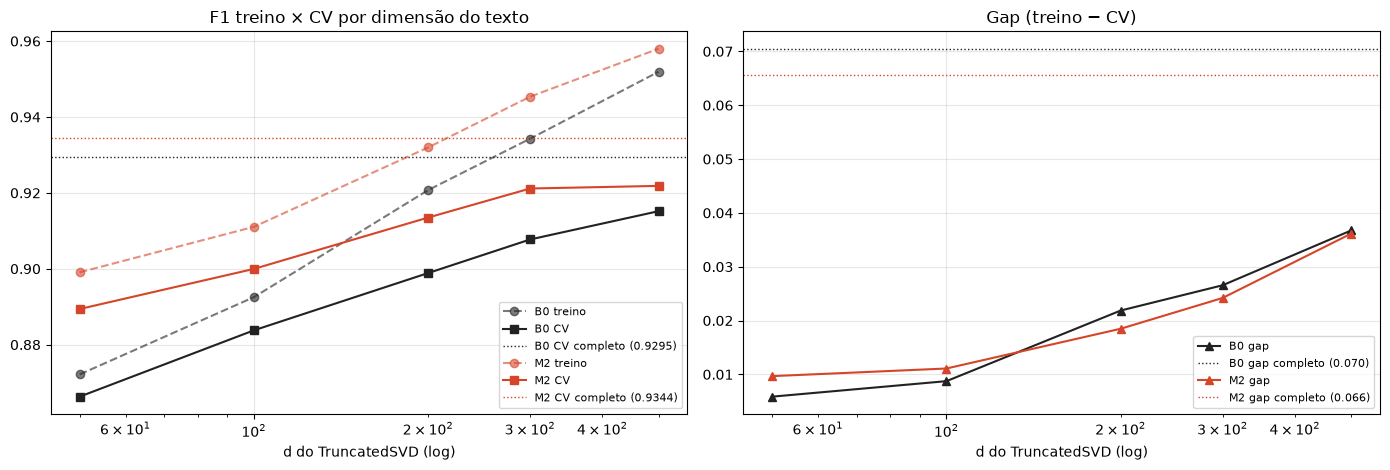

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for cfg, cor in [("B0", "#222222"), ("M2", "#d6452a")]:
    s = res[(res.config == cfg) & (res.d_texto != "all")]
    full = res[(res.config == cfg) & (res.d_texto == "all")].iloc[0]
    d = s.d_texto.astype(int)
    axes[0].plot(d, s.f1_treino, "--o", color=cor, alpha=0.6, label=f"{cfg} treino")
    axes[0].plot(d, s.f1_cv, "-s", color=cor, label=f"{cfg} CV")
    axes[0].axhline(full.f1_cv, color=cor, ls=":", lw=1, label=f"{cfg} CV completo ({full.f1_cv:.4f})")
    axes[1].plot(d, s.gap, "-^", color=cor, label=f"{cfg} gap")
    axes[1].axhline(full.gap, color=cor, ls=":", lw=1, label=f"{cfg} gap completo ({full.gap:.3f})")
for ax, t in zip(axes, ["F1 treino × CV por dimensão do texto", "Gap (treino − CV)"]):
    ax.set_xscale("log"); ax.set_xlabel("d do TruncatedSVD (log)"); ax.set_title(t); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Conclusão:** **o gap cai porque o F1 de treino cai mais que o de validação**, não porque a validação melhora.

| M2 | F1 treino | F1 CV | gap |
|---|---|---|---|
| completo | 1,000 | **0,9344** | 0,066 |
| d=500 | 0,958 | 0,9218 | 0,036 |
| d=300 | 0,945 | 0,9212 | 0,024 |
| d=100 | 0,911 | 0,9000 | 0,011 |
| d=50 | 0,899 | 0,8894 | 0,010 |

- O F1 CV cai em **todo** d, com 0/5 folds melhores. Com d=50 o gap é quase zero, mas o modelo erra ~11% até no treino. Isso é **underfitting**, não aprendizado mais geral.
- **O spaCy pesa mais quando o texto é comprimido.** O ganho do M2 sobre o B0 no mesmo d é de +0,023 (d=50), +0,016 (d=100), +0,015 (d=200), +0,014 (d=300), +0,007 (d=500) e +0,005 (completo). Com o texto reduzido, os 24 metadados passam a carregar uma fração maior do sinal. Ainda assim, nenhum M2 reduzido alcança o texto completo.

## 3. Escolha de d (só CV)

**Pergunta:** algum d reduz o gap mantendo o F1 CV empatado com o M2 completo (Δ ≥ −0,01)?

In [5]:
cand = res[(res.config == "M2") & (res.d_texto != "all")]
validos = cand[cand.delta_vs_m2 >= -0.01]
if len(validos):
    escolhido = validos.sort_values("gap").iloc[0]
    print(f"d escolhido = {escolhido.d_texto}: gap {escolhido.gap:.4f}, Δ vs M2 completo {escolhido.delta_vs_m2:+.4f}")
else:
    escolhido = cand.sort_values("f1_cv").iloc[-1]
    print("Nenhum d mantém o F1 CV dentro de −0,01 do M2 completo.")
    print(f"Para informação, vai ao teste o d com melhor F1 CV: d={escolhido.d_texto} "
          f"(F1 CV {escolhido.f1_cv:.4f}, Δ {escolhido.delta_vs_m2:+.4f}, gap {escolhido.gap:.4f})")
D_ESC = int(escolhido.d_texto)

Nenhum d mantém o F1 CV dentro de −0,01 do M2 completo.
Para informação, vai ao teste o d com melhor F1 CV: d=500 (F1 CV 0.9218, Δ -0.0125, gap 0.0361)


**Conclusão:** **nenhum d passa no critério.**
- O melhor reduzido é o M2 com d=500: F1 CV 0,9218, Δ −0,0125 contra o M2 completo, **0/5 folds** melhores.
- Todos os d perdem do M2 completo em todos os folds.

## 4. Teste interno (`X_te`, uma vez)

**Pergunta:** no teste isolado, como ficam o B0, o M2 completo e o M2 com o d escolhido?

Os modelos são reajustados no `X_tr` completo com o `Pipeline` real. O texto passa por TF-IDF → SVD → Normalizer dentro de um sub-pipeline, e o bloco spaCy recebe peso w via `transformer_weights`.

In [6]:
def para_float32(X):
    return X.astype(np.float32)

def pipeline_real(d, com_meta):
    txt = ColumnTransformer(configs["word+char"])
    if d != "all":
        txt = Pipeline([("tfidf", txt), ("f32", FunctionTransformer(para_float32, accept_sparse=True)),
                        ("svd", TruncatedSVD(n_components=d, random_state=42)), ("norm", Normalizer())])
    trans = [("txt", txt, ["texto_trunc"])]
    pesos = {"txt": 1.0}
    if com_meta:
        trans.append(("meta", meta_pipe(), META_SPACY))
        pesos["meta"] = W
    return Pipeline([("prep", ColumnTransformer(trans, transformer_weights=pesos)), ("clf", clone(SVC))])

def metricas(conjunto, nome, d, y, pipe, X):
    score = pipe.decision_function(X)
    pred = (score > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {"conjunto": conjunto, "config": nome, "d_texto": d, "f1_macro": f1_score(y, pred, average="macro"),
            "roc_auc": roc_auc_score(y, score), "pct_prev_fake": pred.mean(), "tn": tn, "fp": fp, "fn": fn, "tp": tp}

finais = {("B0", "all"): pipeline_real("all", False), ("M2", "all"): pipeline_real("all", True),
          ("M2", D_ESC): pipeline_real(D_ESC, True)}
linhas_teste = []
for (nome, d), pipe in finais.items():
    pipe.fit(X_tr, y_tr)
    linhas_teste.append(metricas("interno (Fake.br X_te)", nome, d, y_te, pipe, X_te))
pd.DataFrame(linhas_teste).round(4)

,conjunto,config,d_texto,f1_macro,roc_auc,pct_prev_fake,tn,fp,fn,tp
0,interno (Fake.br X_te),B0,all,0.9222,0.9830,0.4972,666,54,58,662
1,interno (Fake.br X_te),M2,all,0.9236,0.9846,0.4958,668,52,58,662
2,interno (Fake.br X_te),M2,500,0.9271,0.9805,0.4882,676,44,61,659


**Conclusão:** no teste interno, o M2 com d=500 tem F1 **0,9271**, contra 0,9236 do M2 completo e 0,9222 do B0.
- O AUC vai na direção contrária: **0,9805**, contra 0,9846 e 0,9830.
- As diferenças de F1 (≤ 0,005) estão dentro do erro padrão de ~±0,007, e a CV, que é a medida usada para decidir, mostrou o d=500 **pior** (Δ −0,0125, 0/5 folds).
- O teste não contradiz a CV de forma confiável. O d=500 só troca alguns falsos positivos por falsos negativos (fp 52 → 44, fn 58 → 61).

## 5. Espiada no FakeRecogna (não escolhe nada)

**Pergunta:** fora do domínio, a redução muda a **ordenação** (AUC) ou só o limiar (% previsto fake)?

A montagem é a mesma do notebook 07 e 10: títulos `boatos.org` contra o mesmo número de títulos reais. As features spaCy vêm do cache do notebook 10. Avaliamos todos os d, para B0 e M2, reajustados no `X_tr` completo. Ressalva: títulos de ~13 palavras contra treino de 100 palavras.

In [7]:
def normalizar(texto):
    texto = str(texto)
    texto = texto.translate(str.maketrans({"\x96": "-", "\x97": "-", "\x93": '"', "\x94": '"', "\x91": "'", "\x92": "'"}))
    texto = re.sub(r"[\x80-\x9f]", " ", texto)
    texto = re.sub(r"[–—]", "-", texto)
    texto = re.sub(r"[“”«»]", '"', texto)
    texto = re.sub(r"[‘’]", "'", texto)
    texto = re.sub(r"\s*(?:\[\.*\]|\.{2,}|…)", ".", texto)
    texto = re.sub(r"\d", "0", texto)
    return " ".join(texto.split())

d_ = pd.read_csv("../../data/FakeRecogna.csv")
d_["dominio"] = d_.URL.fillna("").str.extract(r"https?://(?:www\.)?([^/]+)")[0]
fake = d_[(d_.Classe == 0) & (d_.dominio == "boatos.org")].copy()
fake["texto_trunc"] = fake.Titulo.str.replace(r"#boato", "", case=False, regex=True)
real = d_[d_.Classe == 1].sample(len(fake), random_state=42).copy()
real["texto_trunc"] = real.Titulo
ext = pd.concat([fake, real])
ext["texto_trunc"] = ext.texto_trunc.fillna("").map(normalizar)
ext = ext[ext.texto_trunc.str.len() > 0].reset_index(drop=True)
ext["label"] = (ext.Classe == 0).astype(int)
feats_ext = pd.read_parquet("../../data/metadados_spacy_fakerecogna.parquet")  # gerado pelo notebook 10
assert len(feats_ext) == len(ext)
ext = ext.join(feats_ext[META_SPACY])

linhas_ext = []
for nome, com_meta in [("B0", False), ("M2", True)]:
    for d in ["all"] + DIMS:
        pipe = finais.get((nome, d)) or pipeline_real(d, com_meta).fit(X_tr, y_tr)
        linhas_ext.append(metricas("externo (FakeRecogna títulos, espiada)", nome, d, ext["label"], pipe, ext))
        del pipe
        gc.collect()
    print(f"{nome}: ok", flush=True)

teste = pd.DataFrame(linhas_teste + linhas_ext)
teste.round(6).to_csv("../resultados/resultados_m2_reducao_dim_teste.csv", index=False)
print("Salvo: resultados_m2_reducao_dim_teste.csv")
pd.DataFrame(linhas_ext).round(4)

B0: ok


M2: ok


Salvo: resultados_m2_reducao_dim_teste.csv


,conjunto,config,d_texto,f1_macro,roc_auc,pct_prev_fake,tn,fp,fn,tp
0,"externo (FakeRecogna títulos, espiada)",B0,all,0.6119,0.7072,0.7075,1046,1438,407,2077
1,"externo (FakeRecogna títulos, espiada)",B0,50,0.6278,0.6804,0.5465,1446,1038,807,1677
2,"externo (FakeRecogna títulos, espiada)",B0,100,0.6201,0.6773,0.5845,1337,1147,727,1757
3,"externo (FakeRecogna títulos, espiada)",B0,200,0.6287,0.6827,0.5646,1405,1079,758,1726
4,"externo (FakeRecogna títulos, espiada)",B0,300,0.6441,0.6975,0.5588,1457,1027,735,1749
5,"externo (FakeRecogna títulos, espiada)",B0,500,0.6518,0.7069,0.5541,1487,997,728,1756
6,"externo (FakeRecogna títulos, espiada)",M2,all,0.6134,0.6622,0.5934,1300,1184,720,1764
7,"externo (FakeRecogna títulos, espiada)",M2,50,0.6068,0.6533,0.5662,1347,1137,808,1676
8,"externo (FakeRecogna títulos, espiada)",M2,100,0.6014,0.6427,0.5652,1336,1148,824,1660
9,"externo (FakeRecogna títulos, espiada)",M2,200,0.6062,0.6544,0.5288,1435,1049,906,1578


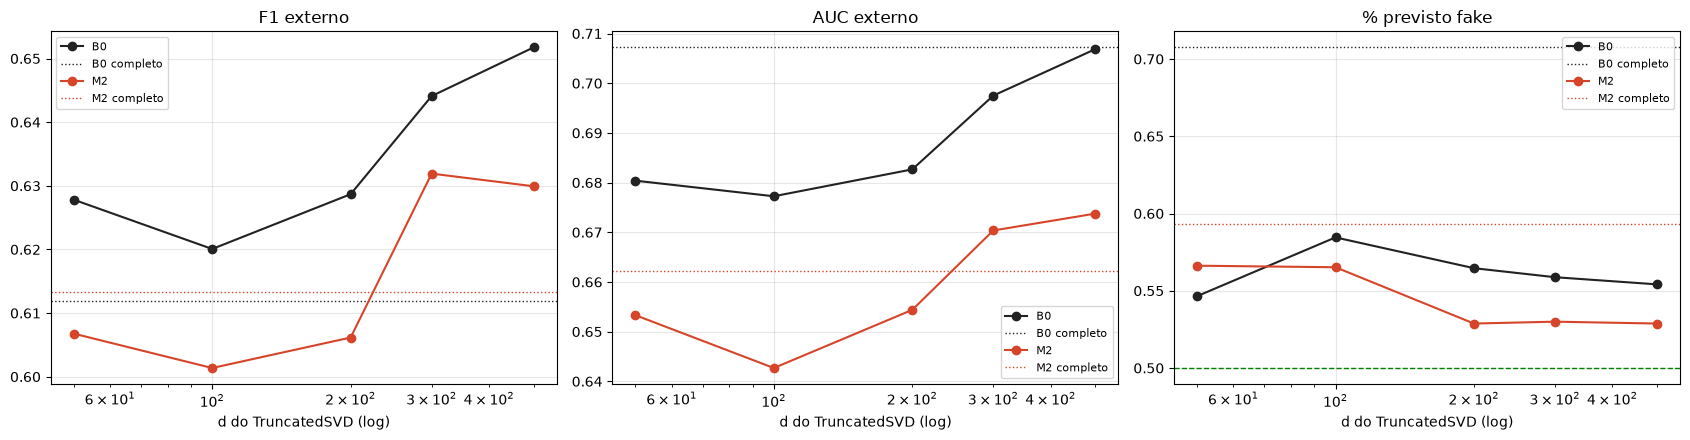

In [8]:
ext_df = pd.DataFrame(linhas_ext)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for nome, cor in [("B0", "#222222"), ("M2", "#d6452a")]:
    s = ext_df[(ext_df.config == nome) & (ext_df.d_texto != "all")]
    full = ext_df[(ext_df.config == nome) & (ext_df.d_texto == "all")].iloc[0]
    d = s.d_texto.astype(int)
    for ax, col in zip(axes, ["f1_macro", "roc_auc", "pct_prev_fake"]):
        ax.plot(d, s[col], "-o", color=cor, label=nome)
        ax.axhline(full[col], color=cor, ls=":", lw=1, label=f"{nome} completo")
for ax, t in zip(axes, ["F1 externo", "AUC externo", "% previsto fake"]):
    ax.set_xscale("log"); ax.set_xlabel("d do TruncatedSVD (log)"); ax.set_title(t); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[2].axhline(0.5, color="green", ls="--", lw=1)
plt.tight_layout()
plt.show()

**Conclusão (espiada, não escolhe nada):** a redução **não melhora a ordenação** fora do domínio. O que muda é só o limiar.
- **B0:**
  - com d=500, o F1 vai de 0,6119 a 0,6518, mas o AUC fica igual (0,7069 contra 0,7072);
  - com d=50, o F1 é 0,6278 e o **AUC cai** para 0,6804.
  - O ganho de F1 vem de o % previsto fake cair de 71% para ~55–58%. Isso reproduz o notebook 07.
- **M2:** o AUC é menor que o do B0 em **todo** d (0,643–0,674 contra 0,677–0,707). O bloco spaCy prejudica a ordenação nos títulos com ou sem redução, pelo mesmo deslocamento de formato visto no notebook 10.

## 6. Conclusões

1. **Reduzir a dimensão do texto não diminui o overfitting de forma útil.** O gap cai de 0,066 para 0,010 (d=50) porque o F1 de treino despenca. O F1 CV cai junto em todos os d (de −0,0125 com d=500 a −0,045 com d=50, 0/5 folds). Gap baixo com F1 baixo é underfitting.
2. **O F1 de treino = 1,0 do modelo completo não indica que ele decora as notícias.** Em d ≫ N com regularização L2, separar o treino é esperado. O que importa é que a validação em notícias não vistas se mantém em ~0,93, e o teste interno confirma (0,92–0,93).
3. **O spaCy compensa parte da perda quando o texto é comprimido** (+0,023 com d=50), mas não o bastante para alcançar o texto completo.
4. **Fora do domínio (espiada):** a redução muda o limiar (menos "fake") e não a ordenação. O AUC fica igual com d=500 e cai com d ≤ 300. O bloco spaCy reduz o AUC em todo d.
5. **O overfitting que realmente preocupa é o de domínio:** o modelo aprende o Fake.br, e não "fake news" em geral. Ele não aparece na CV, porque os folds são do mesmo corpus. Redução de dimensão e metadados spaCy não o resolvem. Para atacá-lo, são necessários dados de treino de outras fontes ou um teste externo com o mesmo formato (texto completo, não títulos).

**Recomendação:** manter o texto completo (sem SVD). Se for preciso um modelo menor por custo, prefira χ² ao SVD (notebooks 08 e 10).